<a href="https://colab.research.google.com/github/r-pranav-git/Deep-Learning-Workshop/blob/main/next_word_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RNN Next Word Prediction**

In [1]:
from google.colab import files
uploaded=files.upload()

Saving next_word_prediction_dataset.txt to next_word_prediction_dataset.txt


In [2]:
filename="next_word_prediction_dataset.txt"
with open(filename,"r",encoding="utf-8") as file:
  text=file.read()
print(text[:500])

Hello how are you today
Hello how are you doing
Hello everyone have a nice day
How are you feeling today
How are you doing this morning
I hope you are doing well
I hope you have a great day
It is a beautiful day today
Today is a wonderful day
The weather is very pleasant today
Once upon a time there was a little rabbit
Once upon a time there lived a little girl
Once upon a time there was a small village
Once upon a time a young boy lived in a forest
There was a little rabbit in the forest
There 


In [3]:
import re
#Convert to lowercase
text=text.lower()
#Remove unwanted symbols
text=re.sub(r"[^a-zA-Z0-9.,!?]"," ",text)
#Remove extra spaces
text=re.sub(r"\s+"," ",text)
print(text[:500])

hello how are you today hello how are you doing hello everyone have a nice day how are you feeling today how are you doing this morning i hope you are doing well i hope you have a great day it is a beautiful day today today is a wonderful day the weather is very pleasant today once upon a time there was a little rabbit once upon a time there lived a little girl once upon a time there was a small village once upon a time a young boy lived in a forest there was a little rabbit in the forest there 


In [4]:
sentences=re.split(r'[.!?]+',text)

#Remove empty sentences
sentences=[s.strip() for s in sentences if len(s.strip())>0]
print("Number of sentences:" , len(sentences))
print(sentences[:5])

Number of sentences: 1
['hello how are you today hello how are you doing hello everyone have a nice day how are you feeling today how are you doing this morning i hope you are doing well i hope you have a great day it is a beautiful day today today is a wonderful day the weather is very pleasant today once upon a time there was a little rabbit once upon a time there lived a little girl once upon a time there was a small village once upon a time a young boy lived in a forest there was a little rabbit in the forest there was a little bird in the garden there was a small house near the river the little rabbit lived in a forest the little rabbit was very happy the little rabbit loved eating carrots the rabbit lived in a beautiful forest the rabbit had many friends the rabbit liked to play with friends the rabbit went into the forest the rabbit walked along the river the rabbit saw a little bird the bird was sitting on a tree the bird sang a beautiful song the forest was very quiet and peac

Tokenization

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(sentences)

total_words = len(tokenizer.word_index) + 1

print("Vocabulary size:", total_words)
print(tokenizer.word_index)

Vocabulary size: 250
{'the': 1, 'rabbit': 2, 'a': 3, 'was': 4, 'forest': 5, 'to': 6, 'they': 7, 'girl': 8, 'little': 9, 'in': 10, 'and': 11, 'day': 12, 'there': 13, 'river': 14, 'small': 15, 'were': 16, 'beautiful': 17, 'bird': 18, 'friends': 19, 'together': 20, 'time': 21, 'flowers': 22, 'you': 23, 'morning': 24, 'garden': 25, 'went': 26, 'walked': 27, 'about': 28, 'are': 29, 'today': 30, 'lived': 31, 'village': 32, 'with': 33, 'one': 34, 'for': 35, 'home': 36, 'children': 37, 'how': 38, 'very': 39, 'once': 40, 'upon': 41, 'carrots': 42, 'many': 43, 'tree': 44, 'through': 45, 'new': 46, 'looked': 47, 'became': 48, 'played': 49, 'dog': 50, 'returned': 51, 'sky': 52, 'hello': 53, 'doing': 54, 'everyone': 55, 'it': 56, 'is': 57, 'wonderful': 58, 'near': 59, 'happy': 60, 'loved': 61, 'had': 62, 'liked': 63, 'saw': 64, 'on': 65, 'quiet': 66, 'peaceful': 67, 'of': 68, 'trees': 69, 'found': 70, 'up': 71, 'food': 72, 'every': 73, 'enjoyed': 74, 'walk': 75, 'birds': 76, 'moved': 77, 'outside':

Convert sentences into sequences

In [6]:
input_sequences = []

for sentence in sentences:

    token_list = tokenizer.texts_to_sequences([sentence])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total sequences:", len(input_sequences))

Total sequences: 963


Find maximum sequence length

In [7]:
max_sequence_length = max(
    len(sequence)
    for sequence in input_sequences
)

print("Maximum sequence length:", max_sequence_length)

Maximum sequence length: 964


Padding

In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

print("Shape:", input_sequences.shape)

Shape: (963, 964)


Separate X and y

In [9]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (963, 963)
y shape: (963,)


Check an example

In [10]:
index = 10

print("Input sequence:", X[index])
print("Target word ID:", y[index])

Input sequence: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  

In [11]:
reverse_word_index = {
    value: key
    for key, value in tokenizer.word_index.items()
}

print("Target word:",
      reverse_word_index.get(y[index], "Unknown"))

Target word: everyone


Build the RNN model

In [12]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_sequence_length - 1
    ),

    tf.keras.layers.SimpleRNN(128),

    tf.keras.layers.Dense(
        total_words,
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [13]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

Train

In [15]:
history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step - accuracy: 0.3437 - loss: 2.8861
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 399ms/step - accuracy: 0.3853 - loss: 2.6541
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 403ms/step - accuracy: 0.4029 - loss: 2.5295
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 414ms/step - accuracy: 0.4226 - loss: 2.3946
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 402ms/step - accuracy: 0.4382 - loss: 2.2630
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 414ms/step - accuracy: 0.4725 - loss: 2.1596
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 415ms/step - accuracy: 0.5016 - loss: 2.0479
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 419ms/step - accuracy: 0.5317 - loss: 1.9458
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 390ms/step - accuracy: 0.5535 - loss: 1.8542
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 394ms/step - accuracy: 0.5826 - loss: 1.7659


Plot accuracy

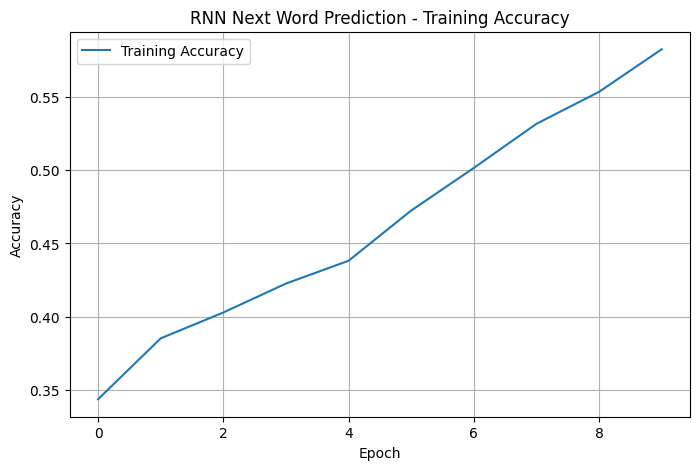

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Next Word Prediction - Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Plot loss

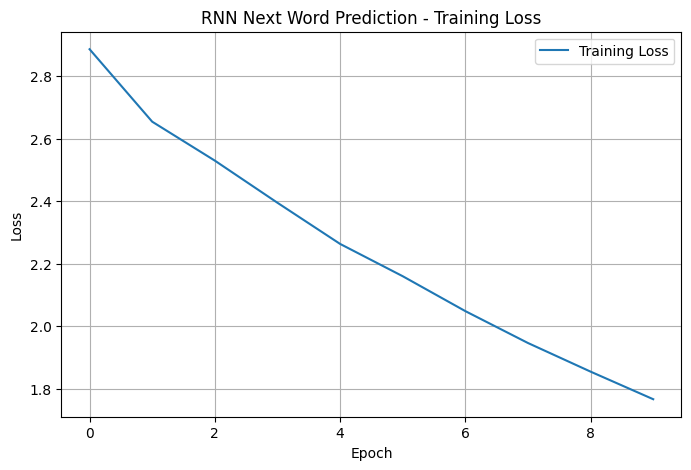

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Next Word Prediction - Training Loss")
plt.legend()
plt.grid(True)

plt.show()

Create prediction function

In [18]:
def predict_next_word(seed_text):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_length - 1,
        padding="pre"
    )

    predicted_probabilities = model.predict(
        token_list,
        verbose=0
    )

    predicted_word_index = np.argmax(
        predicted_probabilities,
        axis=1
    )[0]

    for word, index in tokenizer.word_index.items():

        if index == predicted_word_index:
            return word

    return ""

Test the model

In [20]:
import numpy as np
seed_text = "the rabbit"

next_word = predict_next_word(seed_text)

print("Input:", seed_text)
print("Predicted next word:", next_word)

Input: the rabbit
Predicted next word: they


**Generate multiple words**

In [21]:
def generate_text(seed_text, next_words=5):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_length - 1,
            padding="pre"
        )

        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )

        predicted_word_index = np.argmax(
            predicted_probabilities,
            axis=1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted_word_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [22]:
print(
    generate_text(
        "once upon a time",
        next_words=5
    )
)

once upon a time there was a little rabbit
